# Flow Matching on the 2D Checkerboard

**Phase 2 of the Flow Matching replication** (Lipman et al., 2022, *Flow Matching for Generative Modeling*, arXiv:2210.02747).

This notebook reuses the Phase-1 (8-Gaussian) pipeline almost unchanged and applies it to the **2D checkerboard**, the toy density used in the paper's Figure 4 (left). The goal is to reproduce the paper's central claims on a *different* target:

- **FM-OT** — Flow Matching with the Optimal-Transport conditional path (eq. 20–23).
- **FM-Diff** — Flow Matching with the Variance-Preserving diffusion path (eq. 18–19).
- **SM-Diff** — Score Matching with the VP path (eq. 42–43) — added later, for the H3 stability comparison.

> **Key point: the ODEs and probability paths do *not* change.**
> The FM-OT and VP paths are defined only by the source `N(0, I)` and a single data endpoint `x1`; they never reference *what* the data distribution is. So the conditional paths, target velocity fields, CFM objective, the network, and all ODE solvers are carried over verbatim. Only the **target sampler** and the **evaluation metrics** change — the checkerboard has no discrete modes, so the mode-based metrics from Phase 1 are replaced by cell/support-based ones.

## Research questions and hypotheses

**Main question.** Do FM-OT, FM-Diff, and SM-Diff, trained under identical architecture and optimisation settings, reproduce the paper's findings on the checkerboard as they did on the 8-Gaussian ring?

**Hypotheses** (adapted from Phase 1; H5 is new and checkerboard-specific):

- **H1 — Support recovery.** At high sampling accuracy, all methods reproduce the full checkerboard support (all "on" cells populated, "off" cells empty).
- **H2 — OT sampling efficiency.** FM-OT preserves distribution quality better at low NFE (on-support rate, MMD², sliced-Wasserstein), because its conditional paths are straight, constant-velocity trajectories.
- **H3 — FM vs SM stability.** FM-Diff trains more stably than SM-Diff on the same VP path (pending SM-Diff).
- **H4 — High-NFE convergence.** Method differences shrink once the ODE is solved accurately.
- **H5 — Pattern emergence (new).** The OT path introduces the checkerboard pattern *earlier* along the generative trajectory than the diffusion path (a direct mirror of Fig. 4, left). We test this by measuring on-support rate at intermediate times `t`.

## 1. Environment and configuration

Standard imports. The pipeline is 2D, so it is light enough to run on CPU, but CUDA is used when available (matching Phase 1).

In [211]:
import math
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Use CUDA when available; the whole pipeline is tiny so CPU also works.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.13.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [212]:
# ---- Reproducibility ----
SEED = 42
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")  # faster matmuls on recent GPUs

# ---- Model / optimisation config (identical to Phase 1) ----
DATA_DIM              = 2        # 2D toy data
HIDDEN_DIM            = 512      # MLP width  (paper: 512)
NUM_HIDDEN_LAYERS     = 5        # MLP depth  (paper: 5 hidden layers)
LEARNING_RATE         = 5e-4
NUM_TRAINING_STEPS    = 20_000
BATCH_SIZE            = 2_048    # training mini-batch (fresh samples each step)
VALIDATION_BATCH_SIZE = 4_096
LOG_EVERY             = 100
NUM_PLOT_SAMPLES      = 5_000

# ---- FM-OT config ----
# sigma_min is the residual std at the data endpoint of the OT path (eq. 20).
# Kept identical to Phase 1 so the two experiments are directly comparable.
SIGMA_MIN = 1e-4

print("Model: %d-dim data, %d hidden layers x %d units" % (DATA_DIM, NUM_HIDDEN_LAYERS, HIDDEN_DIM))
print("Training steps:", NUM_TRAINING_STEPS, "| batch:", BATCH_SIZE, "| lr:", LEARNING_RATE)
print("sigma_min:", SIGMA_MIN)

Model: 2-dim data, 5 hidden layers x 512 units
Training steps: 20000 | batch: 2048 | lr: 0.0005
sigma_min: 0.0001


## 2. The checkerboard target distribution

We define a **rigorous** version of the standard 2D checkerboard: the square domain
$[-L, L]^2$ (with $L = 4$) is partitioned into unit cells, and a cell is **"on"** when
$\lfloor x_1 \rfloor + \lfloor x_2 \rfloor$ is even. With $L = 4$ and unit cells there are
$8 \times 8 = 64$ cells, of which exactly **32 are "on"**.

The target density is **uniform on the union of the on-cells**:

$$
q(x) =
\begin{cases}
\dfrac{1}{N_{\text{on}} \cdot A_{\text{cell}}} = \dfrac{1}{32 \cdot 1} = \dfrac{1}{32}, & x \text{ on an on-cell},\\[6pt]
0, & \text{otherwise.}
\end{cases}
$$

Two consequences we will use throughout:

1. **Sampling is exact.** Pick an on-cell uniformly (each with probability $1/32$), then a point uniformly inside it. No rejection needed.
2. **Entropy floor.** The differential entropy of a uniform density on support of area $32$ is $\log 32 \approx 3.4657$ nats ($\approx 1.733$ nats/dim). This is the theoretical minimum for the model NLL.

> **Important caveat for later.** Unlike the Gaussian mixture, this floor is **not reachable** by a continuous CNF: a smooth vector field cannot map a Gaussian onto a density with sharp discontinuities at the cell boundaries. So even a near-perfect model will sit *slightly above* $\log 32$. The gap then measures boundary/smoothness leakage, not a defect — we interpret model NLL accordingly.

In [213]:
# ---- Checkerboard geometry ----
DOMAIN_LIMIT = 4.0     # domain is [-DOMAIN_LIMIT, DOMAIN_LIMIT]^2
CELL_SIZE    = 1.0     # unit cells

# Integer lower-corner indices of every cell: -4, -3, ..., 3  (8 values per axis).
_cell_indices = torch.arange(-DOMAIN_LIMIT, DOMAIN_LIMIT, CELL_SIZE)  # [-4, ..., 3]

# Build the list of "on"-cell lower corners: cell (i, j) is on iff (i + j) is even.
_on_corners = []
for i in _cell_indices:
    for j in _cell_indices:
        if int(i + j) % 2 == 0:                 # even -> "on" cell
            _on_corners.append((float(i), float(j)))

ON_CELL_CORNERS = torch.tensor(_on_corners, dtype=torch.float32)  # shape (N_on, 2)
NUM_ON_CELLS    = ON_CELL_CORNERS.shape[0]
SUPPORT_AREA    = NUM_ON_CELLS * (CELL_SIZE ** 2)
ENTROPY_FLOOR   = math.log(SUPPORT_AREA)         # differential entropy = -log density

print("On-cells:", NUM_ON_CELLS, "| support area:", SUPPORT_AREA)
print("Entropy floor (nats):    ", ENTROPY_FLOOR)
print("Entropy floor (nats/dim):", ENTROPY_FLOOR / DATA_DIM)

On-cells: 32 | support area: 32.0
Entropy floor (nats):     3.4657359027997265
Entropy floor (nats/dim): 1.7328679513998633


In [214]:
def on_checkerboard_support(x: torch.Tensor) -> torch.Tensor:
    """
    Boolean mask: True where x lies on an "on" cell of the checkerboard.

    A point is on-support iff it is inside the domain AND the integer cell it
    falls into, (floor(x1), floor(x2)), satisfies (floor(x1) + floor(x2)) even.
    """
    inside = (x.abs() <= DOMAIN_LIMIT).all(dim=-1)          # within [-L, L]^2
    cell   = torch.floor(x)                                 # integer cell index per point
    parity_even = ((cell[:, 0] + cell[:, 1]) % 2 == 0)      # "on" cells have even parity
    return inside & parity_even

In [215]:
def sample_checkerboard(n_samples: int, device: torch.device) -> torch.Tensor:
    """
    Exact sampler for the uniform checkerboard density.

    Step 1: choose an on-cell uniformly at random (each of the 32 with prob 1/32).
    Step 2: place the point uniformly inside that unit cell.
    """
    corners = ON_CELL_CORNERS.to(device)                    # (N_on, 2) lower corners
    # Uniformly pick one on-cell per sample.
    choice = torch.randint(0, NUM_ON_CELLS, (n_samples,), device=device)
    chosen_corner = corners[choice]                         # (n_samples, 2)
    # Uniform offset within the unit cell.
    offset = torch.rand(n_samples, 2, device=device) * CELL_SIZE
    return chosen_corner + offset

In [216]:
def checkerboard_log_density(x: torch.Tensor) -> torch.Tensor:
    """
    Exact analytical log-density log q(x) of the uniform checkerboard.

    log q(x) = -log(support area) on-support, and -inf off-support.
    (The -inf branch is only used for reference; the model-NLL evaluation later
    always feeds on-support data samples.)
    """
    on_support = on_checkerboard_support(x)
    log_density = torch.full(
        (x.shape[0],), -math.log(SUPPORT_AREA), device=x.device, dtype=x.dtype
    )
    log_density = torch.where(
        on_support, log_density, torch.full_like(log_density, float("-inf"))
    )
    return log_density

In [217]:
# ---- Sanity checks on the target definition ----
_probe = sample_checkerboard(10_000, device)

print("All sampled points on-support:", on_checkerboard_support(_probe).all().item())
print("Sampled log-density (should equal -log 32 = %.4f):" % (-math.log(SUPPORT_AREA)),
      checkerboard_log_density(_probe).mean().item())

# An off-support point (a cell centre with odd parity) must be flagged off-support.
_off = torch.tensor([[0.5, 1.5]], device=device)   # floor -> (0, 1), parity odd -> off
print("Odd-parity point on-support (should be False):", on_checkerboard_support(_off).item())

All sampled points on-support: True
Sampled log-density (should equal -log 32 = -3.4657): -3.465735912322998
Odd-parity point on-support (should be False): False


### 2.1 Visualising the target

A helper to draw the on-cell boundaries is reused in every later plot (it replaces the
mode-centre crosses from Phase 1).

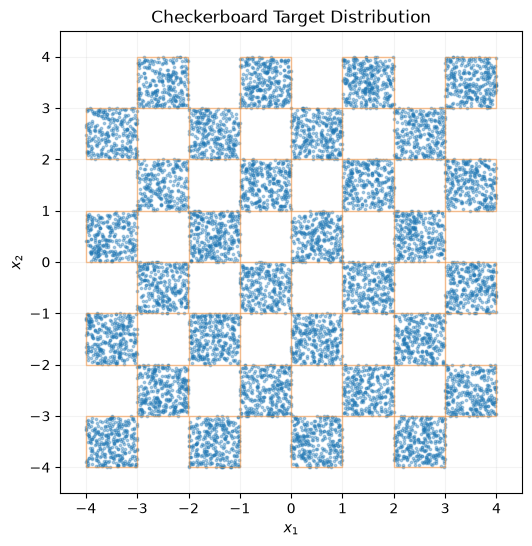

In [218]:
def draw_checkerboard_cells(ax, color="tab:orange", lw=1.0, alpha=0.5):
    """Overlay the outline of every "on" cell so plots show the target support."""
    from matplotlib.patches import Rectangle
    for cx, cy in ON_CELL_CORNERS.tolist():
        ax.add_patch(Rectangle((cx, cy), CELL_SIZE, CELL_SIZE,
                               fill=False, edgecolor=color, lw=lw, alpha=alpha))

# Draw a batch of target samples with the cell overlay.
_vis = sample_checkerboard(NUM_PLOT_SAMPLES * 2, device).cpu()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(_vis[:, 0], _vis[:, 1], s=3, alpha=0.35)
draw_checkerboard_cells(ax)
ax.set_title("Checkerboard Target Distribution")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_xlim(-DOMAIN_LIMIT - 0.5, DOMAIN_LIMIT + 0.5)
ax.set_ylim(-DOMAIN_LIMIT - 0.5, DOMAIN_LIMIT + 0.5)
ax.set_aspect("equal"); ax.grid(alpha=0.15)
plt.show()

## 3. FM-OT conditional probability path

Unchanged from Phase 1 — reproduced here for a self-contained notebook and re-validated on the new target.

The source is $p_0 = \mathcal{N}(0, I)$. For a data point $x_1$, the OT conditional flow (paper eq. 22) is the straight line

$$
\psi_t(x_0) = \bigl(1 - (1 - \sigma_{\min})\,t\bigr)\, x_0 + t\, x_1,
$$

and the corresponding conditional target velocity (eq. 23) is **constant in $t$**:

$$
u_t(x \mid x_1) = x_1 - (1 - \sigma_{\min})\, x_0.
$$

The Conditional Flow Matching (CFM) loss regresses a network $v_\theta(t, x)$ onto $u_t$.

In [219]:
def sample_source(n_samples: int, device: torch.device) -> torch.Tensor:
    """Draw from the standard 2D Gaussian source p0 = N(0, I)."""
    return torch.randn(n_samples, DATA_DIM, device=device)

In [220]:
def fm_ot_state(x0, x1, t, sigma_min: float = SIGMA_MIN):
    """
    Point on the OT conditional path at time t (paper eq. 22):
        psi_t(x0) = (1 - (1 - sigma_min) t) * x0 + t * x1
    t has shape (batch, 1) so it broadcasts over the 2 coordinates.
    """
    coefficient = 1.0 - (1.0 - sigma_min) * t
    return coefficient * x0 + t * x1

In [221]:
def fm_ot_target_velocity(x0, x1, sigma_min: float = SIGMA_MIN):
    """
    Conditional target velocity for the OT path (paper eq. 23):
        u = x1 - (1 - sigma_min) * x0
    Note: independent of t -> constant-direction, constant-speed trajectories.
    """
    return x1 - (1.0 - sigma_min) * x0

In [222]:
def sample_fm_ot_batch(batch_size: int, device: torch.device, sigma_min: float = SIGMA_MIN):
    """
    Build one simulation-free FM-OT training mini-batch:
      x0 ~ N(0, I),  x1 ~ checkerboard,  t ~ U[0, 1],
      xt = psi_t(x0),  ut = conditional target velocity.
    Fresh samples every call -> the loss is an unbiased Monte-Carlo estimate of CFM.
    """
    x0 = sample_source(batch_size, device)
    x1 = sample_checkerboard(batch_size, device)
    t  = torch.rand(batch_size, 1, device=device)
    xt = fm_ot_state(x0, x1, t, sigma_min)
    ut = fm_ot_target_velocity(x0, x1, sigma_min)
    return x0, x1, t, xt, ut

In [223]:
# ---- Validate the path endpoints and the analytic velocity ----
x0, x1, t, xt, ut = sample_fm_ot_batch(BATCH_SIZE, device)

# At t=0 the state must equal x0; at t=1 it must equal x1 (up to sigma_min * x0).
xt_start = fm_ot_state(x0, x1, torch.zeros_like(t))
xt_end   = fm_ot_state(x0, x1, torch.ones_like(t))
print("t=0 state == x0:", torch.allclose(xt_start, x0, atol=1e-6))
print("t=1 state ~= x1:", torch.allclose(xt_end, x1, atol=1e-2))  # sigma_min residual

# The analytic velocity must match a finite-difference derivative of psi_t.
h = 1e-4
fd = (fm_ot_state(x0, x1, t + h) - fm_ot_state(x0, x1, t - h)) / (2 * h)
print("Max |analytic u - finite-diff dpsi/dt|:", (ut - fd).abs().max().item())

t=0 state == x0: True
t=1 state ~= x1: True
Max |analytic u - finite-diff dpsi/dt|: 0.0025420188903808594


### 3.1 How the conditional path morphs noise into the checkerboard

This plot is model-free: it just pushes source samples along $\psi_t$ toward fresh checkerboard
targets at several times. It documents *what the network is asked to learn to reverse-engineer*,
and previews H5 — watch how late the pattern appears along the path.

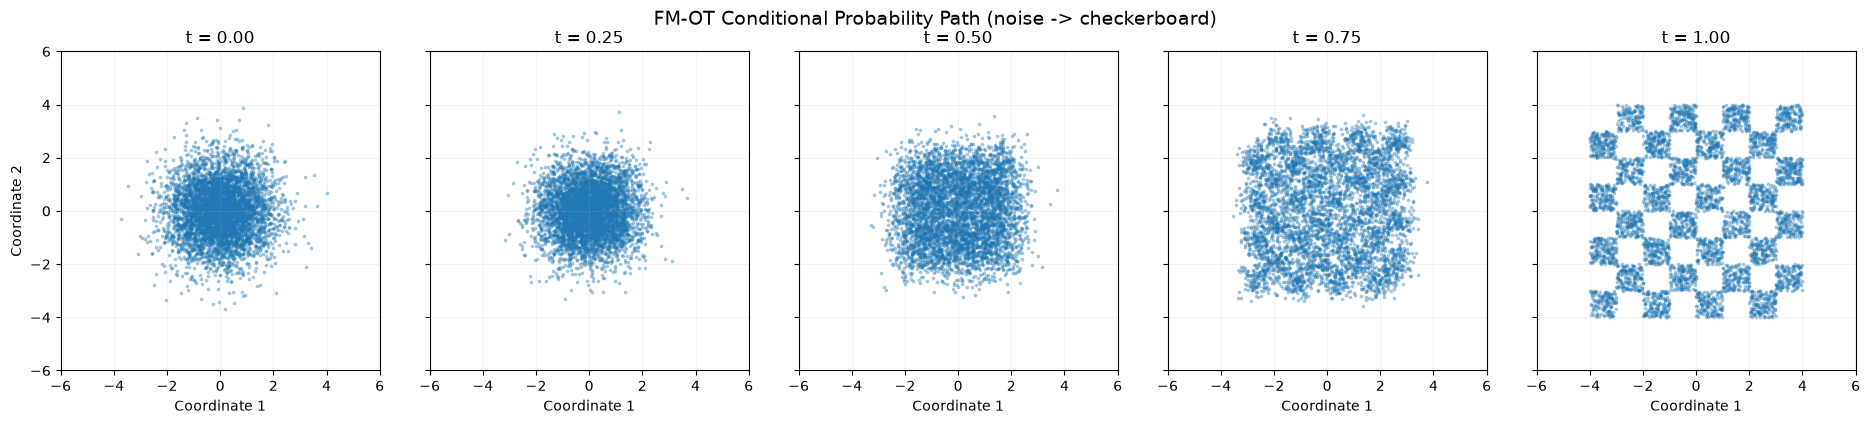

In [224]:
path_times = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, len(path_times), figsize=(19, 4), sharex=True, sharey=True)

x0_vis = sample_source(NUM_PLOT_SAMPLES, device)
x1_vis = sample_checkerboard(NUM_PLOT_SAMPLES, device)

for ax, tv in zip(axes, path_times):
    t_col = torch.full((NUM_PLOT_SAMPLES, 1), tv, device=device)
    state = fm_ot_state(x0_vis, x1_vis, t_col).cpu()
    ax.scatter(state[:, 0], state[:, 1], s=3, alpha=0.3)
    ax.set_title(f"t = {tv:.2f}")
    ax.set_xlabel("Coordinate 1")
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6); ax.set_aspect("equal"); ax.grid(alpha=0.15)
axes[0].set_ylabel("Coordinate 2")
fig.suptitle("FM-OT Conditional Probability Path (noise -> checkerboard)", fontsize=14)
plt.tight_layout(); plt.show()

## 4. Time-conditioned neural vector field

Identical architecture to Phase 1: a time-conditioned MLP $v_\theta(x, t)$ that takes the
concatenation $[x, t] \in \mathbb{R}^{3}$ and outputs a velocity in $\mathbb{R}^{2}$.
Five hidden layers of width 512 with SiLU activations ($\approx 1.05$M parameters).

In [225]:
class FourierFeatures(nn.Module):
    """Random Fourier features: v -> [sin(2*pi*v@B), cos(2*pi*v@B)] with fixed B.
    'scale' sets the frequency band; larger -> sharper spatial structure the MLP can fit."""
    def __init__(self, in_dim, num_frequencies, scale):
        super().__init__()
        # Fixed (non-trainable) Gaussian frequency matrix; buffer so it moves/saves with the model.
        self.register_buffer("B", torch.randn(in_dim, num_frequencies) * scale)
    def forward(self, v):
        proj = 2 * math.pi * (v @ self.B)          # (batch, num_frequencies)
        return torch.cat([proj.sin(), proj.cos()], dim=-1)


class FourierMLP(nn.Module):
    """Same MLP as before, but the input is [x, FourierFeatures(x), t, FourierFeatures(t)].
    This is the only change needed to resolve the checkerboard's sharp cell edges."""
    def __init__(self, data_dim, hidden_dim, num_hidden_layers,
                 x_num_freq=256, x_scale=2.2, t_num_freq=32, t_scale=5.0):
        super().__init__()
        self.x_features = FourierFeatures(data_dim, x_num_freq, x_scale)
        self.t_features = FourierFeatures(1,        t_num_freq, t_scale)
        in_dim = data_dim + 2 * x_num_freq + 1 + 2 * t_num_freq   # raw x + FF(x) + raw t + FF(t)
        layers = [nn.Linear(in_dim, hidden_dim), nn.SiLU()]
        for _ in range(num_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers += [nn.Linear(hidden_dim, data_dim)]
        self.network = nn.Sequential(*layers)
    def forward(self, x, t):
        feats = torch.cat([x, self.x_features(x), t, self.t_features(t)], dim=-1)
        return self.network(feats)


fm_ot_model = FourierMLP(DATA_DIM, HIDDEN_DIM, NUM_HIDDEN_LAYERS).to(device)
n_params = sum(p.numel() for p in fm_ot_model.parameters() if p.requires_grad)
print(fm_ot_model); print("Trainable parameters:", f"{n_params:,}")

FourierMLP(
  (x_features): FourierFeatures()
  (t_features): FourierFeatures()
  (network): Sequential(
    (0): Linear(in_features=579, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): SiLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): SiLU()
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): Linear(in_features=512, out_features=2, bias=True)
  )
)
Trainable parameters: 1,348,610


In [226]:
# Instantiate the Fourier-feature model (replaces TimeConditionedMLP for the checkerboard;
# the raw-MLP version underfit the sharp cell edges — spectral bias — despite hitting the loss floor).
fm_ot_model = FourierMLP(DATA_DIM, HIDDEN_DIM, NUM_HIDDEN_LAYERS).to(device)

n_params = sum(p.numel() for p in fm_ot_model.parameters() if p.requires_grad)
print(fm_ot_model)
print("Trainable parameters:", f"{n_params:,}")

# Quick forward-pass check (signature is unchanged: model(x, t) with x=(B,2), t=(B,1)).
with torch.no_grad():
    _v = fm_ot_model(xt[:128], t[:128])
print("Forward output shape:", tuple(_v.shape), "| all finite:", torch.isfinite(_v).all().item())

FourierMLP(
  (x_features): FourierFeatures()
  (t_features): FourierFeatures()
  (network): Sequential(
    (0): Linear(in_features=579, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): SiLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): SiLU()
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): Linear(in_features=512, out_features=2, bias=True)
  )
)
Trainable parameters: 1,348,610
Forward output shape: (128, 2) | all finite: True


## 5. Training objective and fixed validation batch

The CFM loss is the mean squared velocity error, summed over coordinates:

$$
\mathcal{L}_{\text{CFM}}(\theta) = \mathbb{E}_{t,\,x_0,\,x_1}\bigl\| v_\theta(x_t, t) - u_t(x_t \mid x_1) \bigr\|^2 .
$$

A **fixed** validation batch (frozen once) gives a stable curve to watch, exactly as in Phase 1.

In [227]:
def velocity_matching_loss(predicted_velocity, target_velocity):
    """Mean over the batch of the squared L2 velocity error (summed over coordinates)."""
    return (predicted_velocity - target_velocity).square().sum(dim=-1).mean()

# Frozen validation batch (same generator, drawn once).
torch.manual_seed(SEED + 1)
val_x0, val_x1, val_t, val_xt, val_ut = sample_fm_ot_batch(VALIDATION_BATCH_SIZE, device)
torch.manual_seed(SEED)  # restore
print("Validation batch:", tuple(val_xt.shape))

Validation batch: (4096, 2)


## 6. FM-OT training

Simulation-free training: every step draws a **fresh** mini-batch (no fixed dataset), so each
gradient is an unbiased estimate of the CFM objective. 5000 steps, Adam, lr 5e-4 — identical to Phase 1.

> The training loop is written out explicitly below (rather than hidden in a helper) so the
> per-step logging matches Phase 1 and every line is visible for analysis.

In [228]:
optimizer = torch.optim.Adam(fm_ot_model.parameters(), lr=LEARNING_RATE)
history = {"step": [], "train": [], "val": []}
start = time.time()

for step in range(1, NUM_TRAINING_STEPS + 1):
    # ---- one optimisation step on a fresh simulation-free batch ----
    fm_ot_model.train()
    _, _, t_b, xt_b, ut_b = sample_fm_ot_batch(BATCH_SIZE, device)
    pred = fm_ot_model(xt_b, t_b)
    loss = velocity_matching_loss(pred, ut_b)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # ---- periodic logging on the frozen validation batch ----
    if step % LOG_EVERY == 0 or step == 1:
        fm_ot_model.eval()
        with torch.no_grad():
            val_loss = velocity_matching_loss(fm_ot_model(val_xt, val_t), val_ut)
        history["step"].append(step)
        history["train"].append(loss.item())
        history["val"].append(val_loss.item())
        mem = (torch.cuda.max_memory_allocated() / 1e6) if device.type == "cuda" else 0.0
        print(f"Step {step:5d}/{NUM_TRAINING_STEPS} | "
              f"Train {loss.item():.4f} | Val {val_loss.item():.4f} | "
              f"GPU {mem:6.1f} MB | {time.time()-start:5.1f} s")

print("Training completed.")

Step     1/20000 | Train 12.7635 | Val 12.7939 | GPU  156.6 MB |   0.0 s
Step   100/20000 | Train 7.6856 | Val 7.8712 | GPU  156.6 MB |   0.2 s
Step   200/20000 | Train 7.1911 | Val 7.6438 | GPU  156.6 MB |   0.4 s
Step   300/20000 | Train 7.3583 | Val 7.5758 | GPU  156.6 MB |   0.7 s
Step   400/20000 | Train 7.2402 | Val 7.4669 | GPU  156.6 MB |   0.9 s
Step   500/20000 | Train 6.8364 | Val 7.4495 | GPU  156.6 MB |   1.2 s
Step   600/20000 | Train 7.4758 | Val 7.4607 | GPU  156.6 MB |   1.4 s
Step   700/20000 | Train 6.9115 | Val 7.4750 | GPU  156.6 MB |   1.7 s
Step   800/20000 | Train 7.0421 | Val 7.4175 | GPU  156.6 MB |   1.9 s
Step   900/20000 | Train 6.8666 | Val 7.4551 | GPU  156.6 MB |   2.1 s
Step  1000/20000 | Train 7.2834 | Val 7.4160 | GPU  156.6 MB |   2.4 s
Step  1100/20000 | Train 7.2562 | Val 7.3993 | GPU  156.6 MB |   2.6 s
Step  1200/20000 | Train 7.4216 | Val 7.3927 | GPU  156.6 MB |   2.8 s
Step  1300/20000 | Train 7.3542 | Val 7.3963 | GPU  156.6 MB |   3.1 s
Step

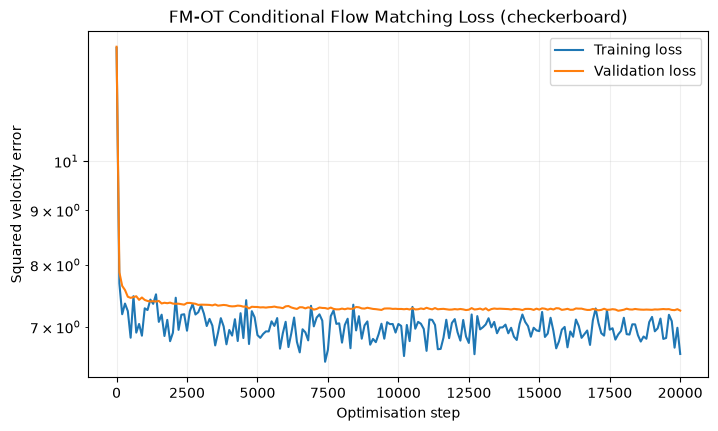

In [229]:
# ---- Loss curves ----
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(history["step"], history["train"], label="Training loss")
ax.plot(history["step"], history["val"],   label="Validation loss")
ax.set_yscale("log")
ax.set_xlabel("Optimisation step"); ax.set_ylabel("Squared velocity error")
ax.set_title("FM-OT Conditional Flow Matching Loss (checkerboard)")
ax.legend(); ax.grid(alpha=0.2)
plt.show()

## 7. Save the FM-OT checkpoint

Saved so the sampling/metric cells (and the FM-Diff comparison) can reload without retraining.

In [230]:
CHECKPOINT_DIR = Path("outputs/checkers")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
torch.save({"model_state": fm_ot_model.state_dict(),
            "config": {"DATA_DIM": DATA_DIM, "HIDDEN_DIM": HIDDEN_DIM,
                       "NUM_HIDDEN_LAYERS": NUM_HIDDEN_LAYERS, "SIGMA_MIN": SIGMA_MIN}},
           CHECKPOINT_DIR / "fm_ot_checkers.pt")
print("Saved:", (CHECKPOINT_DIR / "fm_ot_checkers.pt").resolve())

Saved: /home/kondr/TTrainMethods/TTrainMethods/outputs/checkers/fm_ot_checkers.pt


## 8. ODE samplers (Euler, midpoint, adaptive dopri5)

Sampling integrates $\dot{x} = v_\theta(x, t)$ from $t=0$ (noise) to $t=1$ (data). All three
solvers are carried over from Phase 1 unchanged, including the NFE-counting wrapper. The FM-OT
path is integrated over the full $[0, 1]$; the VP path (FM-Diff, later) will need the
$t = 1-\varepsilon$ endpoint because its velocity is singular at exactly $t=1$.

In [231]:
from torchdiffeq import odeint

class NeuralODEFunction(nn.Module):
    """Adapts v_theta to the torchdiffeq signature f(t, x) and counts NFE."""
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.nfe = 0
    def reset_nfe(self):
        self.nfe = 0
    def forward(self, t, x):
        self.nfe += 1
        t_col = torch.ones(x.shape[0], 1, device=x.device, dtype=x.dtype) * t
        return self.model(x, t_col)

In [232]:
@torch.no_grad()
def euler_integrate(model, x0, num_steps, t_start=0.0, t_end=1.0):
    """Fixed-step explicit Euler. NFE = num_steps."""
    model.eval()
    x = x0.clone()
    dt = (t_end - t_start) / num_steps
    for k in range(num_steps):
        t = t_start + k * dt
        t_col = torch.full((x.shape[0], 1), t, device=x.device, dtype=x.dtype)
        x = x + dt * model(x, t_col)
    return x  # NFE == num_steps

In [233]:
@torch.no_grad()
def midpoint_integrate(model, x0, num_steps, t_start=0.0, t_end=1.0):
    """
    Fixed-step midpoint (RK2). Two model evals per step -> NFE = 2 * num_steps.
    Matches the low-cost solver used in the paper's Fig. 4 (right).
    """
    model.eval()
    x = x0.clone()
    dt = (t_end - t_start) / num_steps
    for k in range(num_steps):
        t = t_start + k * dt
        t_col  = torch.full((x.shape[0], 1), t,          device=x.device, dtype=x.dtype)
        t_half = torch.full((x.shape[0], 1), t + dt / 2, device=x.device, dtype=x.dtype)
        k1 = model(x, t_col)
        k2 = model(x + 0.5 * dt * k1, t_half)
        x = x + dt * k2
    return x  # NFE == 2 * num_steps

In [234]:
DOPRI5_ATOL = 1e-5
DOPRI5_RTOL = 1e-5

@torch.no_grad()
def dopri5_integrate(model, x0, t_start=0.0, t_end=1.0, atol=DOPRI5_ATOL, rtol=DOPRI5_RTOL):
    """
    Adaptive Dormand-Prince solve from t_start to t_end (paper's default at atol=rtol=1e-5).
    Returns (final_state, nfe).
    """
    model.eval()
    ode_fn = NeuralODEFunction(model).to(x0.device)
    ode_fn.reset_nfe()
    times = torch.tensor([t_start, t_end], device=x0.device, dtype=x0.dtype)
    solution = odeint(ode_fn, x0, times, method="dopri5", atol=atol, rtol=rtol)
    return solution[-1], ode_fn.nfe

## 9. Generate samples and qualitative comparison

A fixed evaluation set of source samples is reused across solvers so differences are not due to
randomness. We generate with the adaptive solver and compare against the analytical target, with
the cell overlay. Quantitative evaluation (on-support rate, cell-KL, MMD², sliced-Wasserstein,
model NLL) begins in the next batch.

In [235]:
# Fixed evaluation noise (reused by every solver / method).
NUM_EVAL_SAMPLES = 10_000
torch.manual_seed(SEED + 2)
eval_source = sample_source(NUM_EVAL_SAMPLES, device)
torch.manual_seed(SEED)

# Reference target sample (for side-by-side plots and later metrics).
target_reference = sample_checkerboard(NUM_EVAL_SAMPLES, device)

# Generate with the adaptive solver over the full [0, 1] interval.
t0 = time.time()
fm_ot_generated, fm_ot_nfe = dopri5_integrate(fm_ot_model, eval_source, t_start=0.0, t_end=1.0)
print(f"FM-OT dopri5: NFE={fm_ot_nfe} | {time.time()-t0:.2f}s | "
      f"all finite: {torch.isfinite(fm_ot_generated).all().item()}")

FM-OT dopri5: NFE=128 | 0.34s | all finite: True


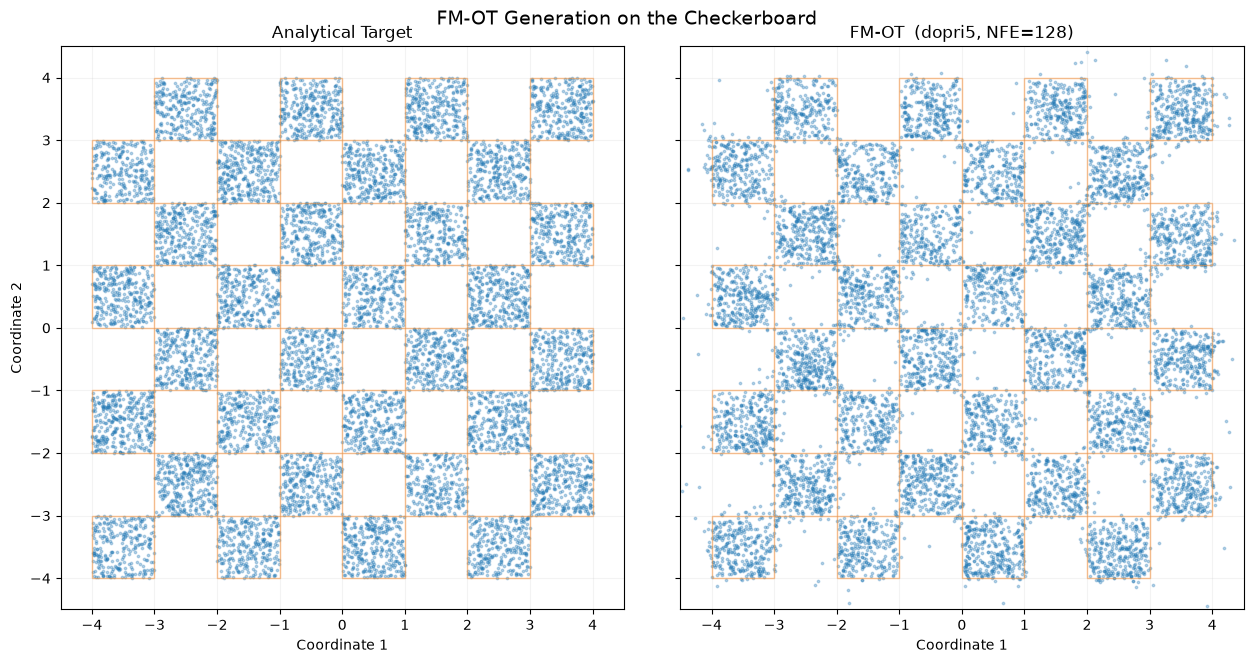

In [236]:
# Side-by-side: analytical target vs FM-OT generated samples.
tgt = target_reference.cpu(); gen = fm_ot_generated.cpu()
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True, sharey=True)

for ax, data, title in [(axes[0], tgt, "Analytical Target"),
                        (axes[1], gen, f"FM-OT  (dopri5, NFE={fm_ot_nfe})")]:
    ax.scatter(data[:, 0], data[:, 1], s=3, alpha=0.3)
    draw_checkerboard_cells(ax)
    ax.set_title(title); ax.set_xlabel("Coordinate 1")
    ax.set_xlim(-DOMAIN_LIMIT - 0.5, DOMAIN_LIMIT + 0.5)
    ax.set_ylim(-DOMAIN_LIMIT - 0.5, DOMAIN_LIMIT + 0.5)
    ax.set_aspect("equal"); ax.grid(alpha=0.15)
axes[0].set_ylabel("Coordinate 2")
fig.suptitle("FM-OT Generation on the Checkerboard", fontsize=14)
plt.tight_layout(); plt.show()

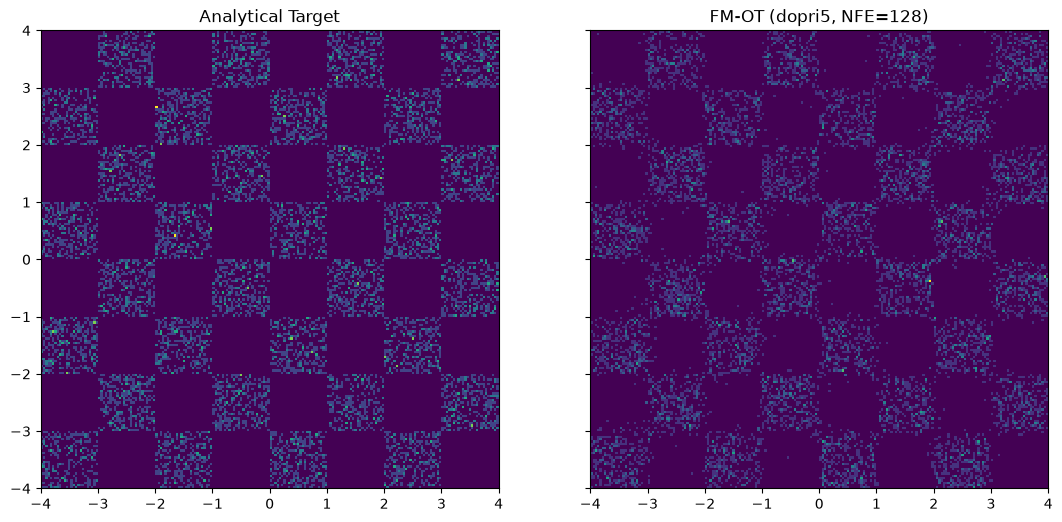

In [237]:
#if we switch to the density plot the result will look much better:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True, sharey=True)
rng = [[-DOMAIN_LIMIT, DOMAIN_LIMIT], [-DOMAIN_LIMIT, DOMAIN_LIMIT]]
for ax, data, title in [(axes[0], tgt, "Analytical Target"),
                        (axes[1], gen, f"FM-OT (dopri5, NFE={fm_ot_nfe})")]:
    ax.hist2d(data[:, 0], data[:, 1], bins=200, range=rng)   # density, like the paper
    ax.set_title(title); ax.set_aspect("equal")
plt.show()

## 10. Checkerboard metric primitives

Phase 1 measured sample quality against *discrete Gaussian modes* (`compute_mode_metrics`):
discovered modes, mode-balance KL, high-quality rate, and mean distance to the nearest centre.
The checkerboard has no modes — it is a piecewise-uniform density on a grid — so those metrics do
not transfer. We replace them with **cell/support-based** analogues on the 8×8 grid, keeping the
same *roles* so the two phases stay comparable:

| Phase-1 (modes) | Checkerboard (cells) | Measures |
|---|---|---|
| High-quality rate (within $3\sigma$ of a centre) | **On-support rate** | fraction of samples landing on an "on" cell |
| Discovered modes (out of 8) | **Cells covered** (out of $N_{\text{on}}$) | how many on-cells receive $\ge$ threshold mass |
| Mode-balance KL | **Cell KL** | imbalance of mass *across* the on-cells |

**Definitions.** Let $\widehat{p}_k$ be the empirical fraction of *on-support* samples in on-cell $k$,
and $p_k = 1/N_{\text{on}}$ the ideal uniform share. Then

$$
\text{on-support rate} = \frac{1}{N}\sum_{i=1}^{N} \mathbb{1}\!\left[x^{(i)} \in \text{support}\right],
\qquad
D_{\mathrm{KL}}(\widehat{p}\,\|\,p) = \sum_{k=1}^{N_{\text{on}}} \widehat{p}_k \log\frac{\widehat{p}_k}{1/N_{\text{on}}}.
$$

**Two deliberate design choices.** First, `cell_kl` is computed only over the *on-support* subset —
it asks "given the mass that landed on-support, is it spread evenly across cells?", so it stays
well-defined even when some mass leaks into the gaps. That leakage is not swept under the rug; it is
captured separately and explicitly by the **on-support rate**. Second, on-support rate is the
metric that carries the paper's efficiency story onto this target: a continuous flow cannot map onto
a discontinuous density without leaving a thin band of mass across cell boundaries, so we expect it
to sit in the low-to-mid 90s% rather than at 1.0, and the interesting question is whether **FM-OT
leaks less than FM-Diff at matched NFE** — the checkerboard analogue of "OT gives better samples at
low compute."

The Phase-1 `Target NLL` proxy (mean $-\log q$ of generated samples under the true density) is
**dropped here**: off-support points have $q = 0 \Rightarrow -\log q = +\infty$, so the mean is
ill-defined. Its role — "do samples land in high-density regions?" — is served directly by the
on-support rate, while the *model's* likelihood is measured properly by the change-of-variables
NLL against the $\log 32 \approx 3.466$ floor (carried over from Phase 1, still an unreachable bound).

In [238]:
## 10. Checkerboard metric primitives (analogue of Phase-1 compute_mode_metrics)
# The checkerboard has no discrete modes, so the mode-based metrics are replaced by
# cell/support-based ones on the 8 x 8 grid:
#   high-quality rate      -> on-support rate      (fraction of samples on an "on" cell)
#   discovered modes       -> cells covered        (on-cells with >= threshold mass, out of NUM_ON_CELLS)
#   mode-KL                -> cell-KL              (empirical mass over on-cells vs uniform 1/NUM_ON_CELLS)
# MMD2, sliced-Wasserstein and model-NLL are unchanged and reused from Phase 1.

# --- one-time lookup: (integer cell index) -> on-cell ordinal, so we can bincount masses ---
_axis_idx  = torch.round(_cell_indices / CELL_SIZE).long()   # e.g. [-4,-3,...,3] for unit cells
_IDX_MIN   = int(_axis_idx.min().item())
_N_AXIS    = _axis_idx.numel()
_CELL_LUT  = torch.full((_N_AXIS, _N_AXIS), -1, dtype=torch.long)   # -1 = off-cell
for _ordinal, (_cx, _cy) in enumerate(ON_CELL_CORNERS.tolist()):
    _ix = int(round(_cx / CELL_SIZE)) - _IDX_MIN
    _iy = int(round(_cy / CELL_SIZE)) - _IDX_MIN
    _CELL_LUT[_ix, _iy] = _ordinal


def compute_cell_metrics(samples: torch.Tensor,
                         discovery_threshold: float = 0.01) -> dict[str, object]:
    """Cell-coverage / balance / on-support quality for the checkerboard.
    Mirrors compute_mode_metrics but keyed on grid cells instead of Gaussian centres."""
    eps = 1e-12
    lut = _CELL_LUT.to(samples.device)

    # On-support mask (fraction on "on" cells) -> the on-support rate.
    on_support = on_checkerboard_support(samples)
    on_support_rate = on_support.float().mean()

    # Integer cell index of every sample, shifted to start at 0 for the lookup table.
    ix = torch.floor(samples[:, 0] / CELL_SIZE).long() - _IDX_MIN
    iy = torch.floor(samples[:, 1] / CELL_SIZE).long() - _IDX_MIN

    # Keep only on-support points that fall inside the index grid (guards off-domain points).
    valid = on_support & (ix >= 0) & (ix < _N_AXIS) & (iy >= 0) & (iy < _N_AXIS)
    ordinals = lut[ix[valid], iy[valid]]                    # on-cell ordinal per on-support point

    counts = torch.bincount(ordinals, minlength=NUM_ON_CELLS).float()
    cell_proportions = counts / counts.sum().clamp(min=1.0)  # empirical mass over the 8 on-cells... (32 here)

    uniform = 1.0 / NUM_ON_CELLS
    cell_kl = (cell_proportions * torch.log((cell_proportions + eps) / uniform)).sum()
    cells_covered = (cell_proportions >= discovery_threshold).sum()

    return {
        "on_support_rate": on_support_rate.item(),
        "cells_covered":   int(cells_covered.item()),   # out of NUM_ON_CELLS
        "cell_kl":         cell_kl.item(),
        "off_support_rate": (1.0 - on_support_rate).item(),
    }